In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### Task 1 -- Both Partners (simultaneously)


In [37]:
region_counts = df["region"].value_counts()
region_counts

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

1. Q: which has the most patients:
A: southeast
2. which has the fewest:
A: northeast

### Task 2

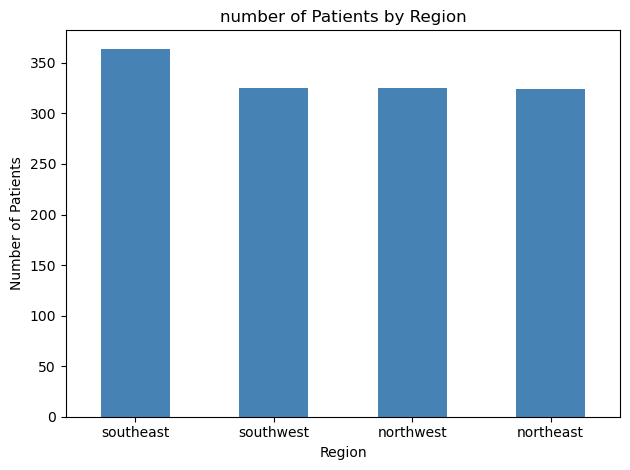

In [38]:
region_counts.plot(kind="bar", 
                   title="number of Patients by Region",
                   xlabel= "Region",
                   ylabel="Number of Patients",
                   color='steelblue',
                   rot=0)
plt.tight_layout()
plt.show()

### Task 3

In [39]:
mean_charges_by_smoker = df.groupby("smoker")["charges"].mean()
mean_charges_by_smoker

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

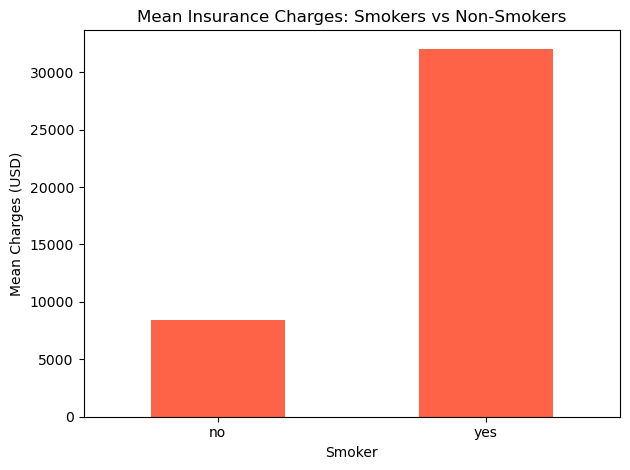

In [40]:
mean_charges_by_smoker.plot(kind='bar',
                            title="Mean Insurance Charges: Smokers vs Non-Smokers",
                            xlabel= "Smoker",
                            ylabel="Mean Charges (USD)",
                            color="tomato",
                            rot=0)
plt.tight_layout()
plt.show()

1. How much higher are charges for smokers?
A: $23,615 on average
2. Does this surprise you?
A: No, because smoking would likely be considered a high risk coverage in insurance due to associated health problems. 

### Task 4

In [41]:
median_charges_by_children = df.groupby("children")["charges"].median()
median_charges_by_children

children
0     9856.95190
1     8483.87015
2     9264.97915
3    10600.54830
4    11033.66170
5     8589.56505
Name: charges, dtype: float64

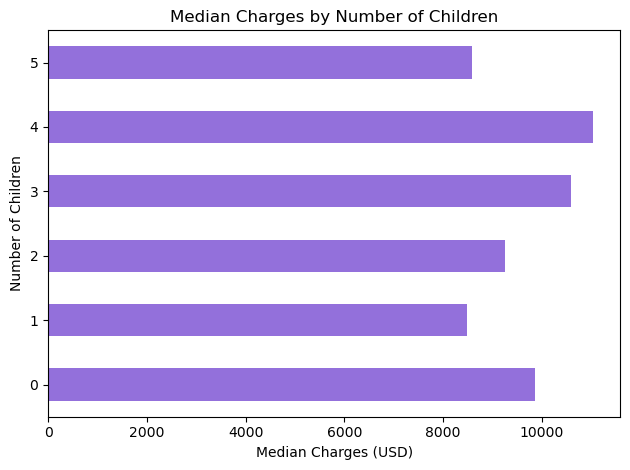

In [42]:
median_charges_by_children.plot(kind="barh",
                                title='Median Charges by Number of Children',
                                xlabel='Median Charges (USD)',
                                ylabel='Number of Children',
                                color='mediumpurple'                                
                                )
plt.tight_layout()
plt.show()

1.Does having more children seem to raise or lower charges?
A: little to no effect on charges. 
2. Do you think children directly cause this pattern, or could something else explain it?
A:  lifestyle differences could cause flux. 0 kids leads to more adventurous life-styles. 5 kids leaves little room for risk adverse activities.

### Task 5

In [43]:
numeric_cols = df[["age","bmi", "children", "charges"]] 
#numeric_cols = df.drop(numeric_only=True)
numeric_cols.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [44]:
corr_matrix = numeric_cols.corr()
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


1. Which columns have the strongest positive relationship?
A: charges and age
2. Which has the strongest negative?
A: no negative correlating columns showed in the matrix
3. Does bmi have a strong or weak relationship with charges?
A: weak

### Task 6

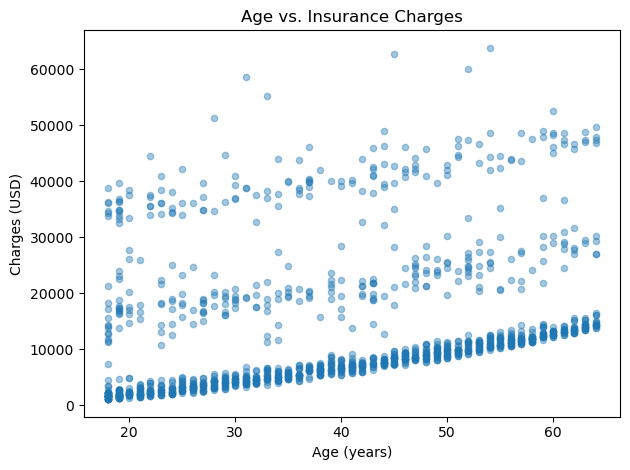

In [45]:
df.plot(kind="scatter",
        x="age",
        y="charges",
        title="Age vs. Insurance Charges",
        xlabel="Age (years)",
        ylabel="Charges (USD)",
        alpha=0.4
)
plt.tight_layout()
plt.show()

1. Does the pattern look like a straight line or something else?
A: curved lines for three distinct groups.
2. Do you notice any clusters or bands of dots?
A: Yes, three clusters
3.Based on the matrix earlier, does the plot match what we expected?
A: It does match

### Task 7

In [46]:
df["smoker_num"] = (df["smoker"] == "yes").astype(int)
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_num'],
      dtype='object')

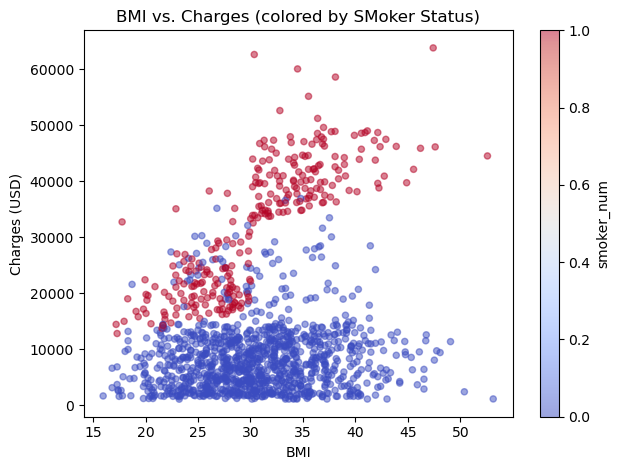

In [47]:
df.plot(kind="scatter",
        x="bmi",
        y="charges",
        c="smoker_num",
        colormap="coolwarm",
        title="BMI vs. Charges (colored by SMoker Status)",
        xlabel="BMI",
        ylabel="Charges (USD)",
        alpha=0.5
        )
plt.tight_layout()
plt.show()



1. Do the two colors form separate clusters?
A: Yes
2. What does this chart tell you?
A: BMI alone does not affect charges as much as if you'd smoke and have a higher BMI.

### Task 8

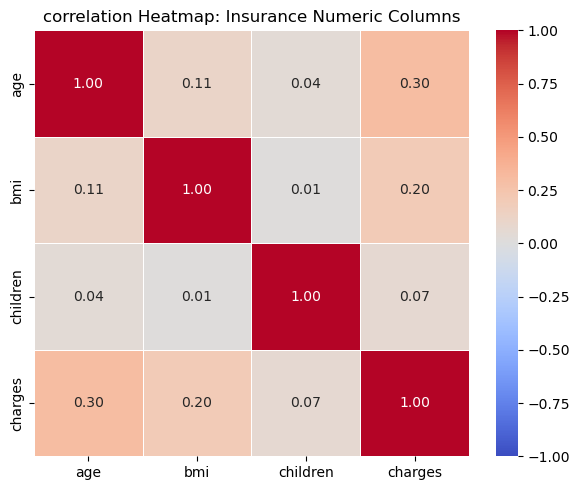

In [49]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr_matrix.round(2),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            ax=ax
            )
ax.set_title("correlation Heatmap: Insurance Numeric Columns")
plt.tight_layout()
plt.show()

In [50]:
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


1. Which cell is the darkest red?
A: age/charges cell
2. which cell is darkest blue?
A: children/bmi
3. Which pairs have correlations close to zero?
A: children/bmi ; children/age
4. Does the heatmap agree with the number you printed in task 5?
A: Yes 

### Task 9

In [51]:
region_charges = df.groupby("region")["charges"].mean()
region_charges

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [57]:
region_charges = region_charges.sort_values(ascending=False)

<Axes: title={'center': 'Average charges per region'}, xlabel='charges', ylabel='region'>

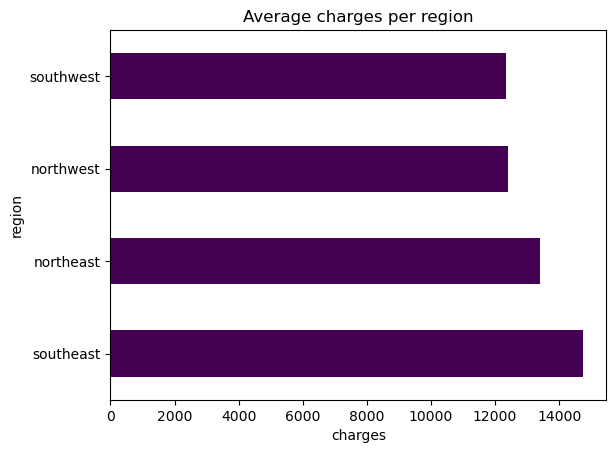

In [58]:
region_charges.plot(kind="barh",
                    colormap="viridis",
                    title="Average charges per region",
                    xlabel="charges",
                    ylabel="region"
                    )

In [59]:
region_charges

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

Is the difference between regions large or small compared to the smoker difference from Task 3?
A:Smaller compared to Task 3 by 10X.

### Task 10

<Axes: title={'center': 'age vs charges'}, xlabel='age', ylabel='charges'>

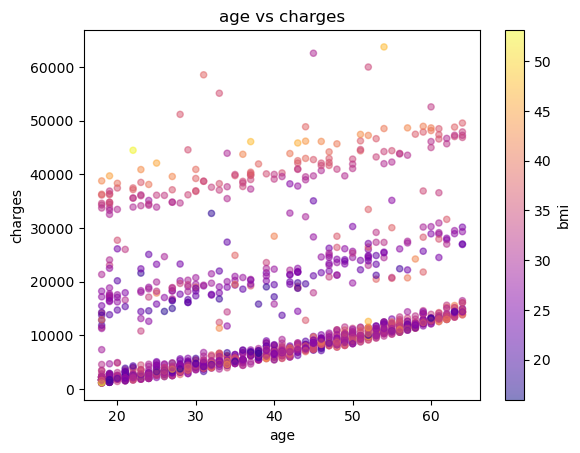

In [60]:
df.plot(kind="scatter",
        x="age",
        y="charges",
        c="bmi",
        colormap="plasma",
        alpha=0.5,
        xlabel="age",
        ylabel="charges",
        title="age vs charges"
        )

1. Does BMI seem to separate the high-charge patients from the low-charge or is the pattern mixed?
A: It does separate with higher BMI on the higher charge spectrum.

### Task 11

In [62]:
smoker_status_gender = df.groupby(["sex","smoker"]).size()
smoker_status_gender

sex     smoker
female  no        547
        yes       115
male    no        517
        yes       159
dtype: int64

In [63]:
unst_smoker = smoker_status_gender.unstack()
unst_smoker

smoker,no,yes
sex,,
female,547,115
male,517,159


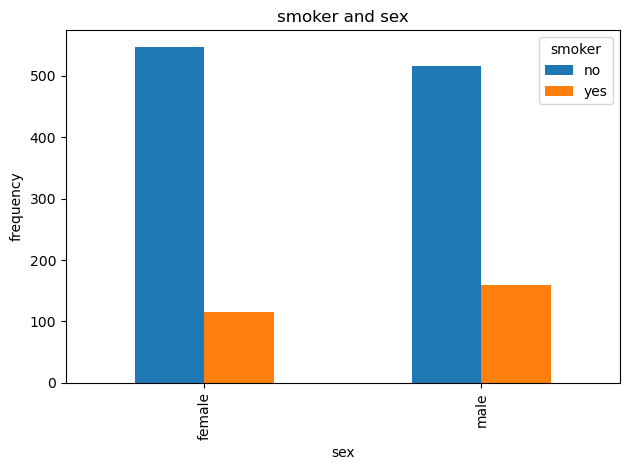

In [66]:
unst_smoker.plot(kind="bar",
                 xlabel="sex",
                 ylabel="frequency",
                 title="smoker and sex"
                 )
plt.tight_layout()
plt.show()

1. Is the smoker split roughly equal between the two? 
A: The split is pretty even with males smoking very slightly more.

### Task 12

In [69]:
focused = df[["age","bmi","charges", "smoker_num"]]
focused = focused.corr()


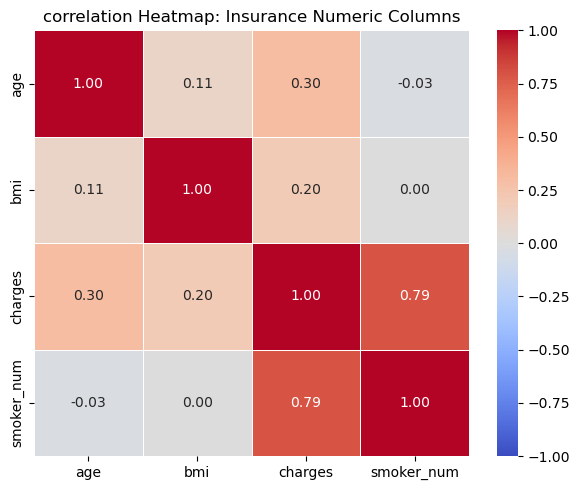

In [70]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(focused.round(2),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            ax=ax
            )
ax.set_title("correlation Heatmap: Insurance Numeric Columns")
plt.tight_layout()
plt.show()

In [71]:
focused

,age,bmi,charges,smoker_num
age,1.000000,0.109272,0.299008,-0.025019
bmi,0.109272,1.000000,0.198341,0.003750
charges,0.299008,0.198341,1.000000,0.787251
smoker_num,-0.025019,0.003750,0.787251,1.000000


### Task 13

1. We chose them based off categorical and numerical representation needs. Bars for categorical and scatter for numerical. Heat maps were used to show correlations.
2. Median charges by number of children. Lifestyle differences would be a third variable not measured which could have explained.
3. BMI vs Charges with "smoker" color codes. BMI showed to have little impact on charges but smoking always raised them. 